**Student Information**

• full name : Marina Youssef Gouda Ramis

• student ID: 3059199

• module name/code: AI Programming

• assignment title: Stroke Prediction - Classification Problem

# **Stroke Prediction - Classification Problem**

-This dataset is directly relevant to the UAE, where the three features our analysis identified as the strongest stroke predictors — elevated glucose, hypertension, and high BMI — are among the most prevalent health conditions in the country.
-Age, BMI, average glucose level, heart disease, hypertension, and marital status are the most influential features in predicting strokes.
-The dataset has 5,110 patient records with 11 features predicting stroke. It originates from electronic health records, originally compiled by McKinsey & Company

**The two biggest challenges you'll face:**
1.Class imbalance — there is a severe imbalance between stroke and non-stroke cases, meaning accuracy alone is a useless metric.
2.Missing BMI values — 201 cases have missing BMI values, representing about 3.93% of the dataset. Dropping these rows loses valuable information

Datasource: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset/data

In [1]:
from cProfile import label
from typing import final

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn import metrics
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, auc

np.random.seed(42)



### Extracting Dataset

In [2]:
url="https://raw.githubusercontent.com/MYGouda/stroke-analysis/main/healthcare-dataset-stroke-data.csv"

df = pd.read_csv(url)
# df=pd.read_csv("healthcare-dataset-stroke-data.csv")

#### EDA and Data cleaning

In [3]:
df.shape


(5110, 12)

In [4]:
df.dtypes


id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [5]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [6]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [8]:
df.isnull().any()    # Detecting Null Values

id                   False
gender               False
age                  False
hypertension         False
heart_disease        False
ever_married         False
work_type            False
Residence_type       False
avg_glucose_level    False
bmi                   True
smoking_status       False
stroke               False
dtype: bool

In [9]:
df['stroke'].value_counts()   #checking for imbalance

stroke
0    4861
1     249
Name: count, dtype: int64

##### Count of fields(people)

###### Stroke =0  count of people 4861

###### Stroke =1  count of people 249

**the data is imbalanced**

In [10]:
df[df['bmi'].isnull()].head()  #Exploring the records of BMI with Null Values

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1


In [11]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

#### Handling missing values
Since the missing values are within BMI, We need to handle these values
the best approach for handling missing values in this dataset is by calculating the median and imputing them into the null records

In [12]:
df['bmi']=df['bmi'].fillna(df['bmi'].median())

In [13]:
df['bmi'].isnull().any()

np.False_

In [14]:
df_strokmean=df.groupby('stroke')['age'].mean()
round(df_strokmean,2)

stroke
0    41.97
1    67.73
Name: age, dtype: float64

Stroke rate is highly related with age with mean value 67.73

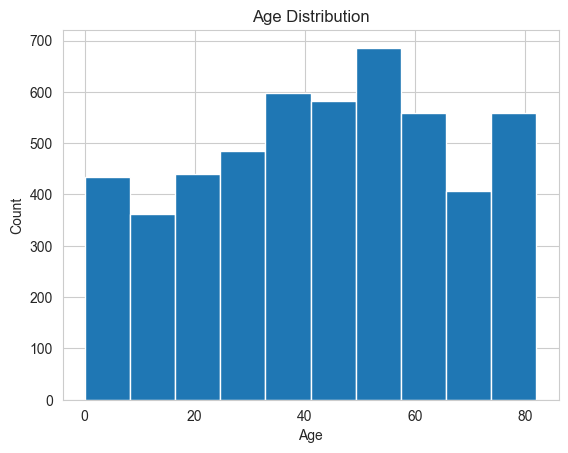

In [15]:
df['age'].hist()
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

From the graph we can see that the higher rates of stroke Counts are around 60-70 years old

we can conclude that there are fewer people with ages higher than 70 = lower counts

In [16]:
stroke_avgglucose=df.groupby('stroke')['avg_glucose_level'].mean()
round(stroke_avgglucose)

stroke
0    105.0
1    133.0
Name: avg_glucose_level, dtype: float64

Stroke rate is highly related with Avg_glucose level with mean value 133.0

In [17]:
#categorial stroke rates

stroke_rates=pd.concat([
    df.groupby(col)['stroke'].mean().rename_axis('Value').reset_index(name='stroke_rate').assign(feature=col)
    for col in ['gender','smoking_status','work_type']
])
stroke_rates['stroke_rate'] = (stroke_rates['stroke_rate'] * 100).round(2)
stroke_rates

,Value,stroke_rate,feature
0,Female,4.71,gender
1,Male,5.11,gender
2,Other,0.00,gender
0,Unknown,3.04,smoking_status
1,formerly smoked,7.91,smoking_status
2,never smoked,4.76,smoking_status
3,smokes,5.32,smoking_status
0,Govt_job,5.02,work_type
1,Never_worked,0.00,work_type
2,Private,5.09,work_type


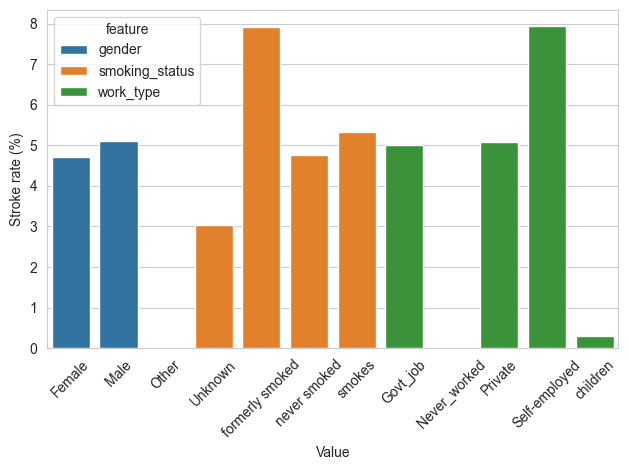

In [18]:
sns.barplot(data=stroke_rates, x='Value', y='stroke_rate', hue='feature')
plt.xticks(rotation=45)
plt.ylabel('Stroke rate (%)')
plt.tight_layout()
plt.show()

1. Males are having higher stroke rates
2. People who are formerly smoked along with Self-employed are having higher stroke rates

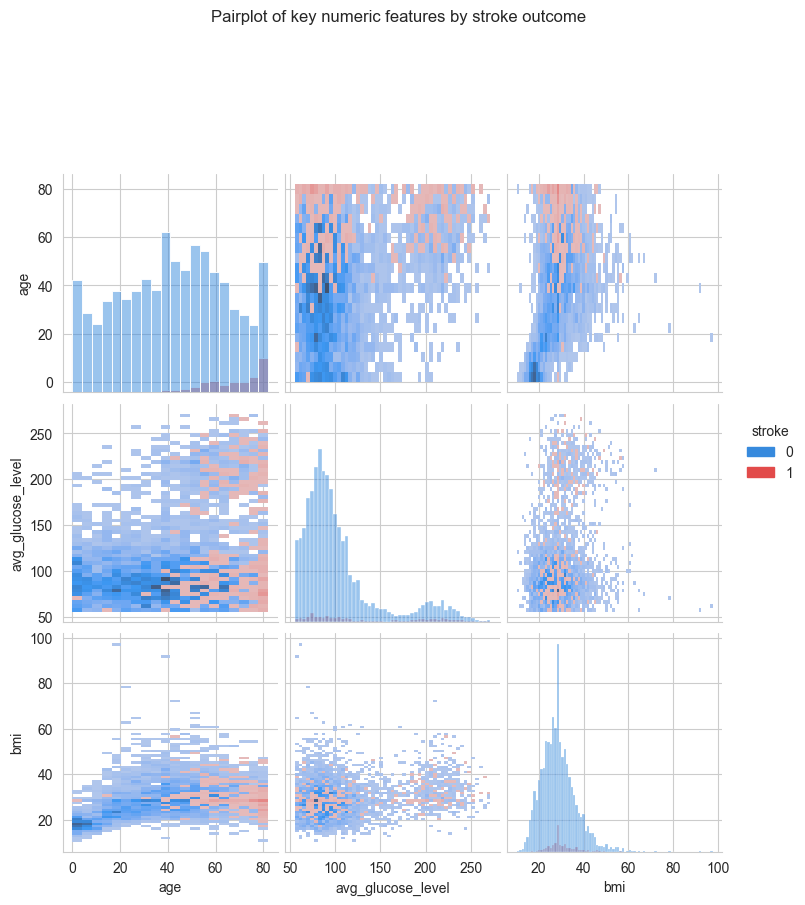

In [19]:
key_features=['age','avg_glucose_level','bmi','stroke']

sns.pairplot(df[key_features], hue='stroke', palette={0:'#378ADD',1:'#E24B4A'},
             kind='hist')
plt.suptitle('Pairplot of key numeric features by stroke outcome',y=1.2)
plt.show()

#### Train Models


##### Baseline model is Random Forest Model , and Improved model is XGBoost

Since we have many categorial data (Gender, Ever_married, Smoking Status and Work type) , we will use **hot encoding** in order to categorize it

In [20]:
#Categoial Columns
cat_col=df[['gender', 'smoking_status', 'work_type', 'ever_married', 'Residence_type']]
cat_col

,gender,smoking_status,work_type,ever_married,Residence_type
0,Male,formerly smoked,Private,Yes,Urban
1,Female,never smoked,Self-employed,Yes,Rural
2,Male,never smoked,Private,Yes,Rural
3,Female,smokes,Private,Yes,Urban
4,Female,never smoked,Self-employed,Yes,Rural
...,...,...,...,...,...
5105,Female,never smoked,Private,Yes,Urban
5106,Female,never smoked,Self-employed,Yes,Urban
5107,Female,never smoked,Self-employed,Yes,Rural
5108,Male,formerly smoked,Private,Yes,Rural


In [21]:
#Categorical variables were encoded using one-hot encoding to make them suitable for machine learning models.
one_hot_encoder=OneHotEncoder(sparse_output=False)
cat_encoded=one_hot_encoder.fit_transform(cat_col)
print(cat_encoded)

[[0. 1. 0. ... 1. 0. 1.]
 [1. 0. 0. ... 1. 1. 0.]
 [0. 1. 0. ... 1. 1. 0.]
 ...
 [1. 0. 0. ... 1. 1. 0.]
 [0. 1. 0. ... 1. 1. 0.]
 [1. 0. 0. ... 1. 0. 1.]]


In [22]:
#Numerical Columns
df_num=df.drop(columns=cat_col)
df_num

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,9046,67.0,0,1,228.69,36.6,1
1,51676,61.0,0,0,202.21,28.1,1
2,31112,80.0,0,1,105.92,32.5,1
3,60182,49.0,0,0,171.23,34.4,1
4,1665,79.0,1,0,174.12,24.0,1
...,...,...,...,...,...,...,...
5105,18234,80.0,1,0,83.75,28.1,0
5106,44873,81.0,0,0,125.20,40.0,0
5107,19723,35.0,0,0,82.99,30.6,0
5108,37544,51.0,0,0,166.29,25.6,0


In [23]:
#Extractiong the names of the columns to merge within the dataset
encoded_cat_df= pd.DataFrame(
    cat_encoded,
    columns=one_hot_encoder.get_feature_names_out()
).reset_index(drop=True)
encoded_cat_df

,gender_Female,gender_Male,gender_Other,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,ever_married_No,ever_married_Yes,Residence_type_Rural,Residence_type_Urban
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
5106,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
5107,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
5108,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [24]:
#Merging the Categorial and Numerical Columns
final_df=pd.concat([df_num,encoded_cat_df],axis=1)
final_df


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,...,smoking_status_smokes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,ever_married_No,ever_married_Yes,Residence_type_Rural,Residence_type_Urban
0,9046,67.0,0,1,228.69,36.6,1,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,51676,61.0,0,0,202.21,28.1,1,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,31112,80.0,0,1,105.92,32.5,1,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,60182,49.0,0,0,171.23,34.4,1,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1665,79.0,1,0,174.12,24.0,1,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,80.0,1,0,83.75,28.1,0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
5106,44873,81.0,0,0,125.20,40.0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
5107,19723,35.0,0,0,82.99,30.6,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
5108,37544,51.0,0,0,166.29,25.6,0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [25]:
#splitting the data
features=final_df.columns.difference(['stroke'])
X=final_df[features]
y=final_df['stroke']


X_train,X_test, y_train,y_test= train_test_split(
    X,y, test_size=0.4, random_state=42
)    #setting test data size to 40%

In [26]:
#applying SMOTE for handling imbalanced data
smote=SMOTE(random_state=42)
X_train, y_train=smote.fit_resample(X_train,y_train)

In [27]:
#applying Random Forest Classifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
print(type(rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


#### Prediction and Evaluation

In [28]:
y_predict= rf.predict(X_test)
print('Confusion Matrix: \n',confusion_matrix(y_test,y_predict))
print('Classification Report: \n',classification_report(y_test,y_predict))

Confusion Matrix: 
 [[1923    7]
 [ 113    1]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      1930
           1       0.12      0.01      0.02       114

    accuracy                           0.94      2044
   macro avg       0.53      0.50      0.49      2044
weighted avg       0.90      0.94      0.92      2044



What each number means:
- True Negatives (TN) 1927 Correctly predicted NO stroke
- False Positives (FP) 3 Predicted stroke, actually no stroke
- False Negatives (FN) 113 Missed 113 real stroke cases
- True Positives (TP) 1 Correctly caught only 1 stroke case

**The problem is clear**

Out of 114 real stroke patients in your test set, it only caught 1. It missed 113. In a medical context this is dangerous — these are patients who would be sent home undiagnosed.

Text(0.5, 0.98, 'Confusion Matrix')

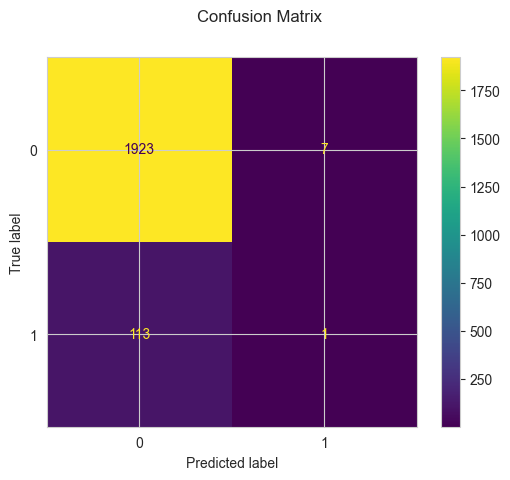

In [29]:
disp= metrics.ConfusionMatrixDisplay.from_predictions(y_test,y_predict)
disp.figure_.suptitle('Confusion Matrix')

To fix this issue we need **XGBoost Model** by Increasing class_weight penalty

In [30]:
XGBoost=XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=20,   # increased from previous value
        eval_metric='logloss',
        random_state=42
    )
XGBoost.fit(X_train,y_train)
print(type(XGBoost))

<class 'xgboost.sklearn.XGBClassifier'>


In [31]:
y_prediction= XGBoost.predict(X_test)
print('Confusion Matrix: \n',confusion_matrix(y_test,y_prediction))
print('Classification Report: \n',classification_report(y_test,y_prediction))

Confusion Matrix: 
 [[1544  386]
 [  47   67]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.80      0.88      1930
           1       0.15      0.59      0.24       114

    accuracy                           0.79      2044
   macro avg       0.56      0.69      0.56      2044
weighted avg       0.92      0.79      0.84      2044



Numbers improved significantly
- True Negatives (TN) 1544 Correctly predicted NO stroke
- False Positives (FP) 386 Predicted stroke, actually no stroke
- False Negatives (FN) 47 Missed 47 real stroke cases
- True Positives (TP) 67 Correctly caught only 67 stroke case

Text(0.5, 0.98, 'Confusion Matrix')

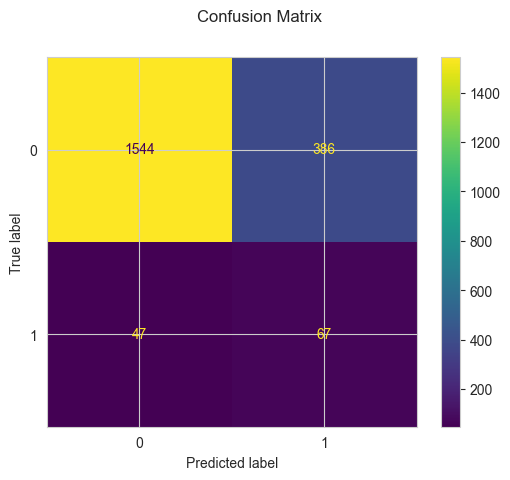

In [32]:
disp= metrics.ConfusionMatrixDisplay.from_predictions(y_test,y_prediction)
disp.figure_.suptitle('Confusion Matrix')

In [33]:
roc_auc_score(y_test,XGBoost.predict_proba(X_test)[:,1])

0.7740296336696662

we can see the score test is almost 78%, lets validate by ROC-Curve

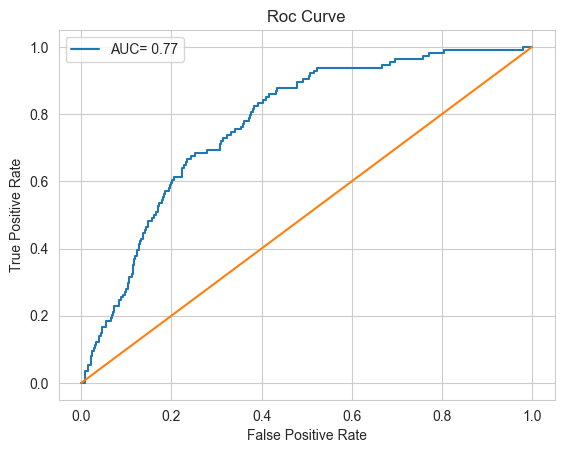

In [34]:
y_probs= XGBoost.predict_proba(X_test)[:,1]
fpr, tpr, threshold = roc_curve(y_test,y_probs)
roc_auc=auc(fpr,tpr)

plt.figure()
plt.plot(fpr,tpr, label=f'AUC= {roc_auc:.2f}')
plt.plot([0,1],[0,1])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Roc Curve')
plt.legend()

plt.show()

#### Key Findings
The analysis confirmed that stroke risk prediction from routine clinical and demographic data is feasible using supervised machine learning, but requires careful handling of class imbalance to produce clinically meaningful results.

**Age** emerged as the single strongest predictor of stroke across every diagnostic applied — correlation analysis.

**Average glucose level and hypertension** were the next most influential features, consistent with established clinical literature.

**Class imbalance** was the dominant technical challenge.

**XGBoost outperformed Rainforest Model** on AUC-ROC and recall, capturing non-linear relationships between features that the linear baseline could not.

#### Limitations

**1. Confidential data provenance**
The originating institution is listed as confidential by the dataset author. This makes it impossible to fully assess how patients were selected, whether the sample is representative, or what data collection protocols were followed — all of which affect how far the findings can be generalised.

**2. Geographic generalisability**
The dataset was compiled from an unspecified population. Its applicability to the UAE — where demographic profiles, diet, and healthcare access differ — cannot be assumed without validation on local clinical data.

**3. Small positive class**
Only 249 stroke cases exist in the full dataset (~4.9%). No matter how sophisticated the resampling strategy, the model has very few real examples of stroke to learn from. SMOTE generates synthetic cases but cannot substitute for genuine patient data.